# Practical 6: reading enhancers with a deep learning model

**ISN Neurochemistry School 2026**

In Practical 5 you found regions of the genome that are open in one cell type and
closed in others, and you saved two of them. You know *where* they are. You do
not know *why* they are open in those cells.

The DNA sequence itself should carry the answer. A region is accessible in a
Kenyon cell because it contains short words, motifs, that Kenyon cell
transcription factors recognise and bind.

In this practical you use two pretrained networks to ask:

> Given only the 500 nucleotides of a sequence, can a model tell which cell type
> it is open in? Which nucleotides is it using? And do two different models agree?

No training happens here. Both models are already trained, and every prediction
takes under a second on a laptop CPU.

## 0. Setup

Two environment variables have to be set **before** anything is imported.

- `KERAS_BACKEND` tells Keras to use PyTorch
- `KERAS_TORCH_DEVICE` pins the computation to the CPU. Without it, Keras uses
  the GPU on Apple Silicon Macs, which cannot handle the number format CREsted
  uses for contribution scores, and section 6 fails with an error.

In [1]:
import os

os.environ["KERAS_BACKEND"] = "torch"
os.environ["KERAS_TORCH_DEVICE"] = "cpu"

import sys
from pathlib import Path

ROOT = Path.cwd()
while not (ROOT / "pyproject.toml").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import crested

# Loading these two parts of crested switches matplotlib to a file-only
# backend, which stops figures appearing in the notebook. Load them now and
# then restore the notebook backend, so that every plot below is displayed.
_ = crested.tl, crested.pl
%matplotlib inline
import matplotlib.pyplot as plt

print("crested", crested.__version__)

2026-09-23T16:48:17.983144+0200 INFO Lazily importing module crested.tl. This could take a second...


/Users/u0132293/Documents/software/coursework/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


2026-09-23T16:48:25.557095+0200 INFO Lazily importing module crested.pl. This could take a second...


crested 1.10.0


## 1. The first model

**DeepFlyBrain** was trained by Janssens et al. on the same adult brain ATAC data
you used in Practical 5. It is a convolutional neural network:

- **input:** 500 base pairs of DNA, written as A, C, G, T
- **output:** 81 numbers between 0 and 1

Each output is called a **topic**. A topic is a group of genomic regions that
tend to be open in the same cells. The authors found these groups first, then
trained the model to recognise them from sequence alone.

In [2]:
model_path, output_names = crested.get_model("DeepFlyBrain")
model = crested.utils.load_model(model_path, compile=False)

print("input shape: ", model.input_shape)
print("output shape:", model.output_shape)
print("first outputs:", output_names[:5])

input shape:  (None, 500, 4)
output shape: (None, 81)
first outputs: ['Topic_1', 'Topic_2', 'Topic_3', 'Topic_4', 'Topic_5']


### Topics are not cell types

The outputs are called `Topic_1` to `Topic_81`, which says nothing on its own.
The authors annotated 26 of the 81 with the cell type they correspond to and
left the rest unlabelled. `scripts/deepflybrain_topics.py` holds that table,
taken from the legend on the flybrain.aertslab.org portal.

In [3]:
from scripts.deepflybrain_topics import TOPIC_CELL_TYPE

annotated = sorted(TOPIC_CELL_TYPE)
topic_index = [n - 1 for n in annotated]                       # positions in the output
topic_labels = [f"{TOPIC_CELL_TYPE[n]} ({n})" for n in annotated]

print(f"{len(annotated)} of 81 topics have a cell type.")
print("The other 55 were never annotated, so a high score there cannot be read.")

25 of 81 topics have a cell type.
The other 55 were never annotated, so a high score there cannot be read.


The annotated topics cover Kenyon cells, T neurons and glia, because those are
the cells the model was trained on. Three topics correspond to BEAF-32, an
insulator protein rather than a cell type.

## 2. The genome

To turn a region such as `chr2R:19346269-19346769` into 500 nucleotides we need the
dm6 genome sequence, downloaded during setup.

In [4]:
from scripts.download_data import dm6_genome

genome = crested.Genome(dm6_genome())
crested.register_genome(genome)

  already here: dm6.fa (147 MB)
2026-09-23T16:48:25.882670+0200 INFO Genome dm6 registered.


## 3. The regions from Practical 5

Practical 5 wrote its candidate regions to a file. Each is exactly 500 bp,
because that is what both models expect.

In [5]:
regions = pd.read_csv(
    ROOT / "data" / "processed" / "practical5_candidate_regions.bed",
    sep="\t", header=None, names=["chrom", "start", "end", "note"],
)
regions["region"] = (regions["chrom"] + ":" + regions["start"].astype(str)
                     + "-" + regions["end"].astype(str))

kc_region = regions.loc[regions["note"].str.contains("Kenyon"), "region"].iloc[0]
glia_region = regions.loc[regions["note"].str.contains("astrocyte"), "region"].iloc[0]

kc_seq, glia_seq = crested.utils.fetch_sequences([kc_region, glia_region], genome)
print("Kenyon cell region:", kc_region, len(kc_seq), "bp")
print("glial region:      ", glia_region, len(glia_seq), "bp")

Kenyon cell region: chr2R:19346269-19346769 500 bp
glial region:       chr3R:18232201-18232701 500 bp


## 4. Asking the model what a region is

Start with the glial region, the one near `repo`.

Before running the next cell: if the model works, which bars should be tall?

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step


2026-09-23T16:48:25.976339+0200 WARNING Argument `x_label_rotation` is renamed in v1.7.0; please use xtick_rotation instead.


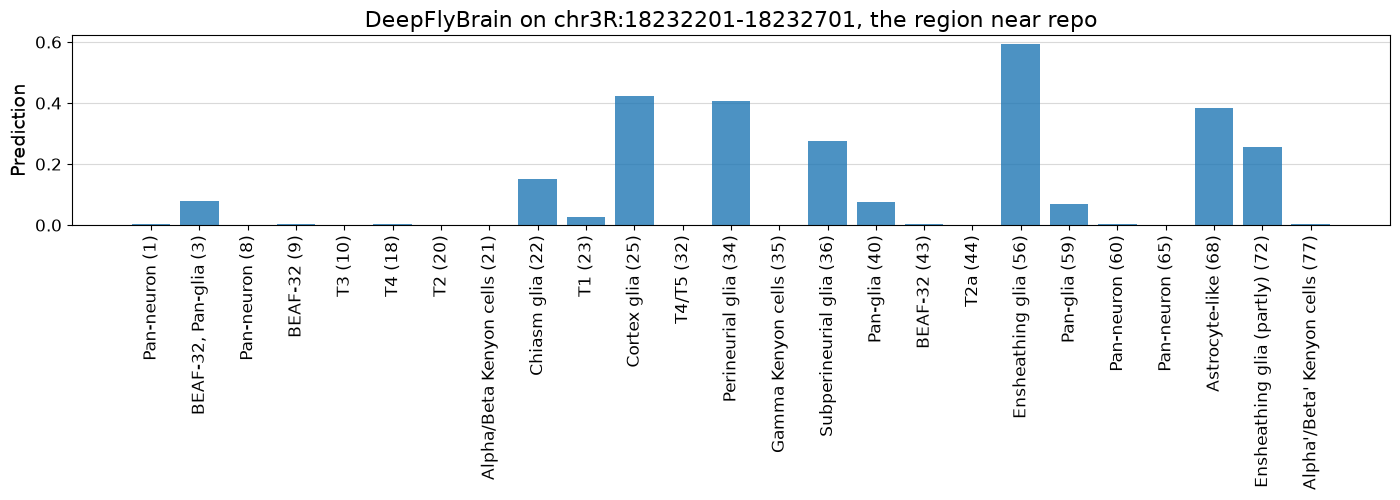

In [6]:
glia_prediction = crested.tl.predict(glia_seq, model).ravel()

crested.pl.region.bar(
    data=glia_prediction[topic_index],
    classes=topic_labels,
    title=f"DeepFlyBrain on {glia_region}, the region near repo",
    width=14, height=5, x_label_rotation=90,
)

Every glial topic has a bar: ensheathing, cortex, perineurial, astrocyte-like,
subperineurial and chiasm glia. Every Kenyon cell and T neuron topic sits at
zero.

The model was given 500 nucleotides and nothing else, and it placed the region in
glia. The information really is in the sequence.

Note that the model says "glia" rather than "astrocyte" specifically. Glial types
share much of their regulatory programme, so this is a reasonable answer rather
than a failure.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step


2026-09-23T16:48:26.217490+0200 WARNING Argument `x_label_rotation` is renamed in v1.7.0; please use xtick_rotation instead.


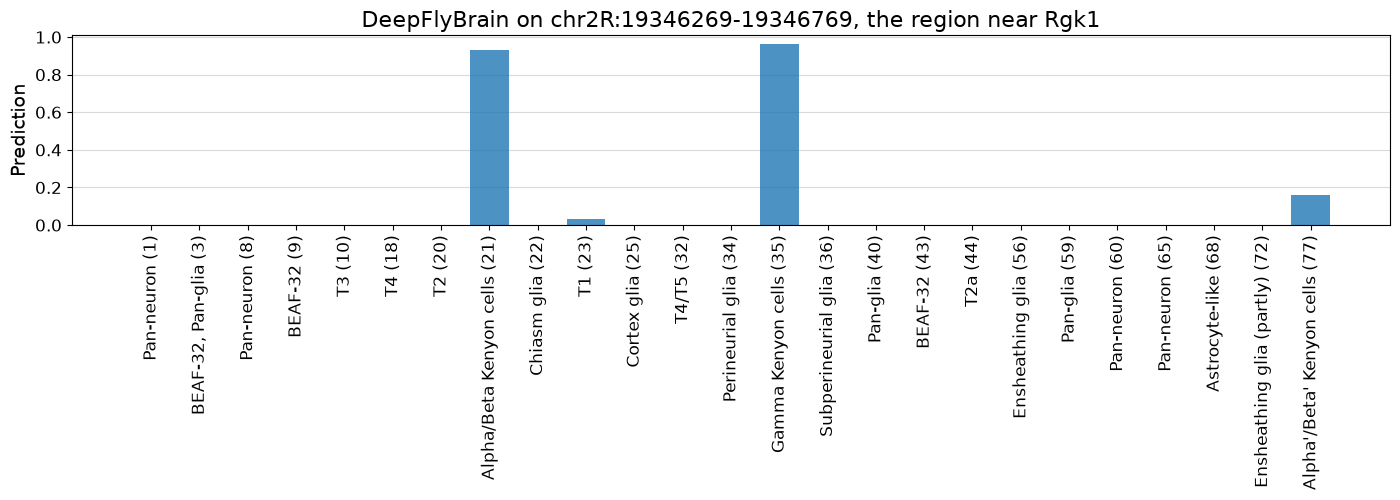

In [7]:
kc_prediction = crested.tl.predict(kc_seq, model).ravel()

crested.pl.region.bar(
    data=kc_prediction[topic_index],
    classes=topic_labels,
    title=f"DeepFlyBrain on {kc_region}, the region near Rgk1",
    width=14, height=5, x_label_rotation=90,
)

The pattern is inverted. The Kenyon cell topics are now the tall bars, gamma
Kenyon cells reaching about 0.96 out of a possible 1.0, and the glial topics have
dropped to zero.

Same model, same 81 outputs, two sequences, opposite answers.

Recall where this region came from. In Practical 5 the differential expression
test named `Rgk1` one of the strongest gamma Kenyon cell markers, and this
accessible region sits beside `Rgk1`. Three independent lines of evidence now
agree: the gene is expressed in Kenyon cells, the region beside it is open in
Kenyon cells, and a model that sees only sequence calls it a Kenyon cell region.

## 5. A second model, trained on different cells

DeepFlyBrain was trained on Kenyon cells, T neurons and glia of the adult brain,
so those are the only things it can report. Rather than take that on trust,
compare it with a model trained on something else.

**Embryo10x** was trained by Dickmanken et al. (2026) on ATAC data from whole
*Drosophila* embryos, 16 to 20 hours after egg laying. Like DeepFlyBrain it takes
500 bp of dm6 sequence.

Two differences matter:

- its 20 outputs are **named cell types**, not topics, so no lookup table is
  needed
- it is a **peak regression** model. It predicts the height of the ATAC peak in
  each cell type, rather than a probability between 0 and 1. Its numbers are on a
  different scale from DeepFlyBrain's, so compare the ranking within a model,
  never the size of a number between models.

In [8]:
embryo_path, embryo_classes = crested.get_model("Embryo10x")
embryo_model = crested.utils.load_model(embryo_path, compile=False)

embryo_classes = list(embryo_classes)
print(len(embryo_classes), "cell types, named directly:")
print(", ".join(embryo_classes))

20 cell types, named directly:
Epidermis, Fat_body, Glia, Head_Ectoderm, Hemocytes, Hindgut, Malpighian_Tubule, Midgut, Midgut_acidification, Neuroblasts, Neuronal, PNS_sens_neurons, Pharynx, Primordium_all, Salivary_gland, Somatic_muscles, Tracheal_system, Visceral_muscles, Yolk, muscle_attachment_Stripe


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


2026-09-23T16:48:26.641489+0200 WARNING Argument `x_label_rotation` is renamed in v1.7.0; please use xtick_rotation instead.


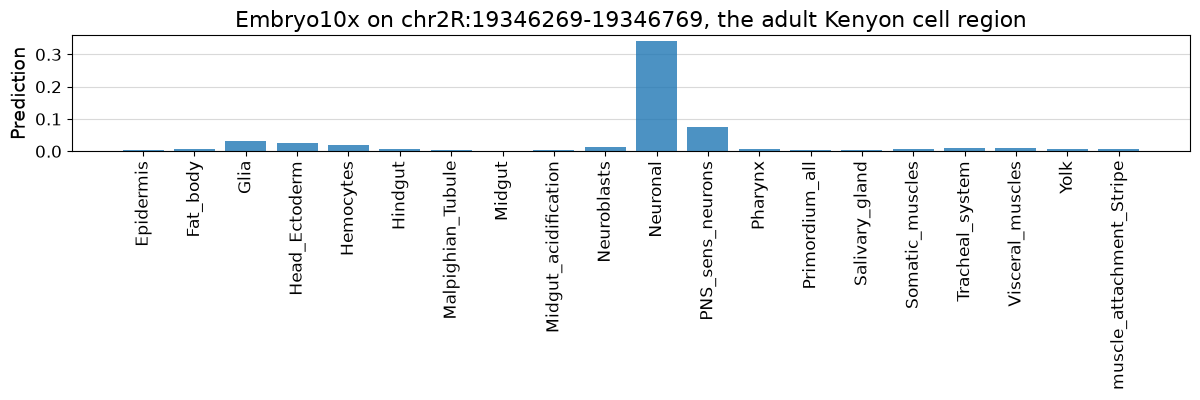

In [9]:
crested.pl.region.bar(
    data=crested.tl.predict(kc_seq, embryo_model).ravel(),
    classes=embryo_classes,
    title=f"Embryo10x on {kc_region}, the adult Kenyon cell region",
    width=12, height=4, x_label_rotation=90,
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


2026-09-23T16:48:26.755220+0200 WARNING Argument `x_label_rotation` is renamed in v1.7.0; please use xtick_rotation instead.


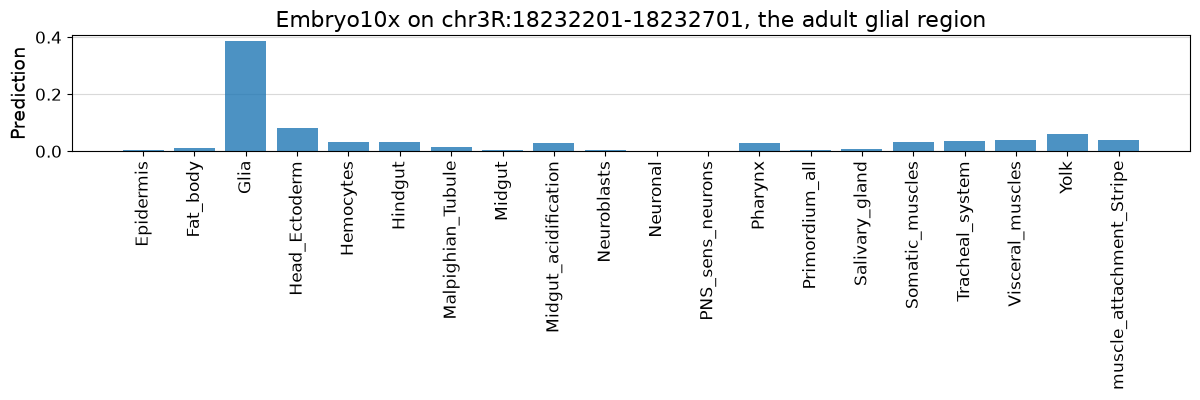

In [10]:
crested.pl.region.bar(
    data=crested.tl.predict(glia_seq, embryo_model).ravel(),
    classes=embryo_classes,
    title=f"Embryo10x on {glia_region}, the adult glial region",
    width=12, height=4, x_label_rotation=90,
)

The embryo model puts `Neuronal` on top for the Kenyon cell region and `Glia` on
top for the glial region. It has never seen an adult brain, yet it still
separates a neuronal from a glial sequence. The distinction between neuron and
glia is written into the DNA early and stays recognisable.

What it cannot do is go further. Its best answer for the Kenyon region is
"Neuronal", because its training data contained no Kenyon cells and no mushroom
body. DeepFlyBrain, trained on exactly those cells, named gamma Kenyon cells.

> A model can only answer about the cell types it was trained on. Its vocabulary
> is its training data.

## 6. Which nucleotides matter?

A prediction is one number. We can also ask which nucleotides produced it.

For this we switch to regions the authors tested **in the fly**. Janssens et al.
cloned candidate enhancers in front of a reporter gene and looked at where each
was active; the 54 public ones are in `enhancersTested.bed`. For an arbitrary
accessible region we would have no way to judge whether the model's explanation
is sensible. For these, activity was measured.

In [11]:
from scripts.download_data import janssens_tested_enhancers

tested = pd.read_csv(janssens_tested_enhancers(), sep="\t", header=None,
                     names=["chrom", "start", "end", "name"])
tested["centre"] = (tested["start"] + tested["end"]) // 2
tested["region"] = (tested["chrom"] + ":" + (tested["centre"] - 250).astype(str)
                    + "-" + (tested["centre"] + 250).astype(str))

print(len(tested), "enhancers tested in vivo")
tested.head()

Janssens et al. 2022 - enhancers tested in vivo
  already here: enhancersTested.bed (0.0 MB)
54 enhancers tested in vivo


,chrom,start,end,name,centre,region
0,chrX,18552058,18553789,enh14,18552923,chrX:18552673-18553173
1,chr3L,9525431,9526414,enh19,9525922,chr3L:9525672-9526172
2,chr2R,10442344,10442886,enh21,10442615,chr2R:10442365-10442865
3,chr2L,20050798,20051699,enh49,20051248,chr2L:20050998-20051498
4,chr3R,11450825,11451124,enh60,11450974,chr3R:11450724-11451224


Start with **enh47**, the one Figure 4 of the paper dissects. It lies near
*sNPF*, the reporter is active in gamma Kenyon cells, and the figure annotates
four transcription factor motifs in it: **Sr**, **Mef2**, **Ey** and **Onecut**.
Mutating the Ey and Mef2 sites reduces its activity.

Because the answer is known in advance, this is a fair test of the method rather
than a demonstration.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step


2026-09-23T16:48:26.957830+0200 WARNING Argument `x_label_rotation` is renamed in v1.7.0; please use xtick_rotation instead.


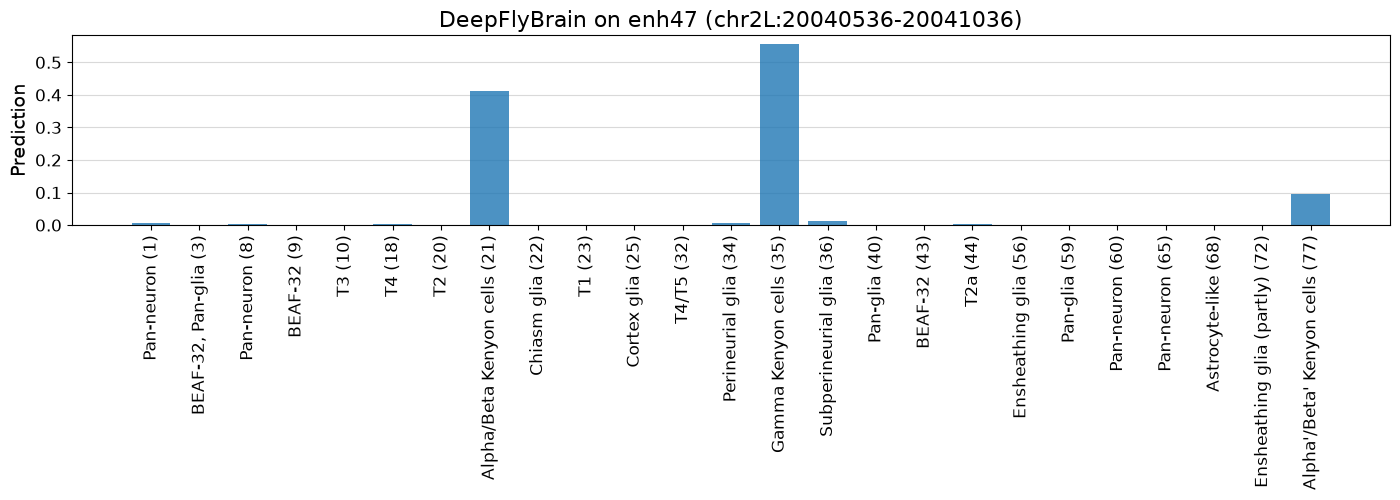

In [12]:
enh_name = "enh47"
enh_region = tested.loc[tested["name"] == enh_name, "region"].iloc[0]
enh_seq = crested.utils.fetch_sequences([enh_region], genome)[0]

crested.pl.region.bar(
    data=crested.tl.predict(enh_seq, model).ravel()[topic_index],
    classes=topic_labels,
    title=f"DeepFlyBrain on {enh_name} ({enh_region})",
    width=14, height=5, x_label_rotation=90,
)

### Contribution scores

A **contribution score** gives every nucleotide a value: positive if it pushes
the prediction up, negative if it pushes it down. CREsted computes them with
integrated gradients, which takes a fraction of a second.

`target_idx` selects which of the 81 outputs to explain, counting from zero, so
`Topic_35` is index 34.

> There is a second method, `method="mutagenesis"`, which substitutes every
> nucleotide with each alternative and re-predicts. It is easier to describe but
> much slower, seconds to tens of seconds per sequence, and its output is better
> read as a heatmap. Integrated gradients is the practical choice here.

In [13]:
enh_scores, enh_onehot = crested.tl.contribution_scores(
    [enh_seq],
    target_idx=34,                  # Topic_35, gamma Kenyon cells
    model=model,
    method="integrated_grad",
    genome=genome,
)

def importance(scores):
    """How much the model depends on each nucleotide, ignoring direction."""
    return np.abs(scores[0, 0]).sum(axis=1)

imp = importance(enh_scores)
print("contributions computed:", enh_scores.shape)

2026-09-23T16:48:27.078791+0200 INFO Calculating contribution scores for 1 region(s) and 1 class(es).


Model:   0%|          | 0/1 [00:00<?, ?it/s]

Model: 100%|██████████| 1/1 [00:00<00:00,  2.27it/s]

Model: 100%|██████████| 1/1 [00:00<00:00,  2.26it/s]

contributions computed: (1, 1, 500, 4)


### Which motifs are there?

CREsted ships a database of 7,446 known motifs with a table mapping them to fly
transcription factors. `scripts/motifs.py` pulls out the matrix for a named
factor and scans the sequence on both strands.

Finding a motif is not enough on its own, because a 500 bp sequence contains
matches to something by chance. The useful question is whether a match sits
where the model is actually looking, so we score each hit by how far its
contribution exceeds the average for this sequence.

In [14]:
from scripts.motifs import scan

def motifs_the_model_uses(sequence, contributions, tfs, threshold=0.75, min_ratio=1.5):
    """Motif matches that also carry above-average contribution."""
    per_base = importance(contributions)
    hits = scan(sequence, tfs, threshold=threshold)
    if not len(hits):
        return hits
    hits["x_average"] = [
        round(float(per_base[h.start:h.end].mean() / per_base.mean()), 2)
        for h in hits.itertuples()
    ]
    return (hits[hits["x_average"] >= min_ratio]
            .sort_values("x_average", ascending=False)
            .drop_duplicates("tf")
            .sort_values("start")
            .reset_index(drop=True))

found = motifs_the_model_uses(enh_seq, enh_scores,
                              ["Mef2", "ey", "sr", "onecut"], threshold=0.70)
found

,tf,start,end,strand,sequence,score,x_average
0,Mef2,307,318,+,CTATTAATAAA,0.723,2.51
1,onecut,347,355,-,TATCGATT,0.938,2.42


### Marking them on the plot

`highlight_positions` draws a box at given coordinates. The plotting function
returns its figure and axes, so the transcription factor name can be written
above each box.

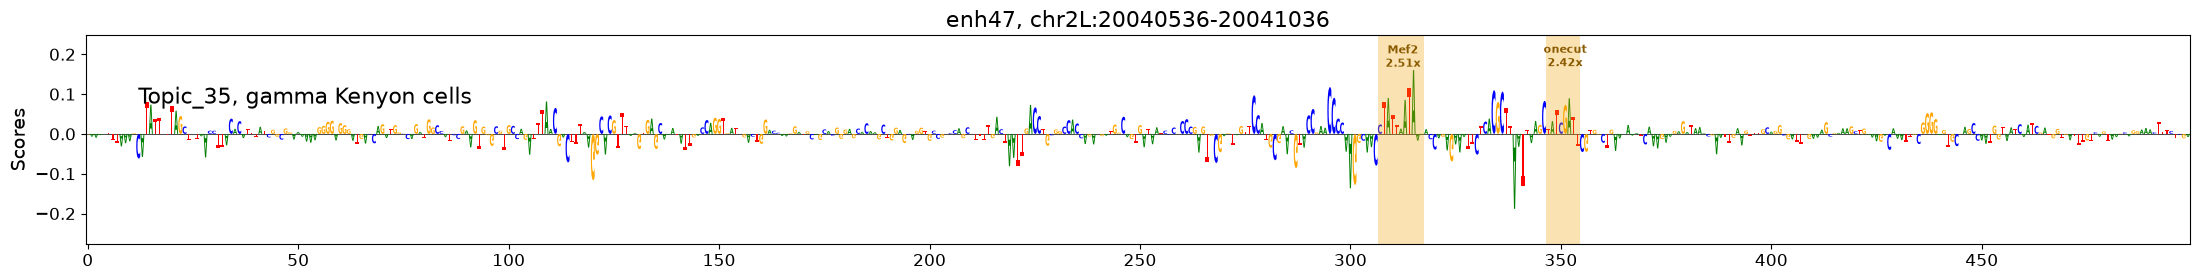

In [15]:
def plot_with_motifs(scores, onehot, hits, label, class_label, width=22, height=3):
    fig, axes = crested.pl.explain.contribution_scores(
        scores, onehot,
        sequence_labels=[label], class_labels=[class_label],
        highlight_positions=[(int(h.start), int(h.end)) for h in hits.itertuples()],
        highlight_kws={"facecolor": "#f0a202", "alpha": 0.30, "edgecolor": "none"},
        width=width, height=height, show=False,
    )
    ax = axes[0] if isinstance(axes, (list, np.ndarray)) else axes
    top = ax.get_ylim()[1]
    for h in hits.itertuples():
        ax.text((h.start + h.end) / 2, top * 0.92, f"{h.tf}\n{h.x_average}x",
                ha="center", va="top", fontsize=8, weight="bold", color="#8a5a00")
    plt.show()

plot_with_motifs(enh_scores, enh_onehot, found,
                 f"{enh_name}, {enh_region}", "Topic_35, gamma Kenyon cells")

Two of the four motifs are recovered, **Mef2** and **Onecut**, and both sit on
stretches the model depends on, at about 2.5 and 2.4 times the average
contribution for this sequence. Mef2 is one of the two factors the authors
mutated, so the model and the experiment agree.

The model was never told what either motif looks like. It learned them from
accessibility data alone.

**Sr and Ey are not recovered**, even at this lower threshold. Both facts are
worth taking seriously rather than glossing over:

- a position weight matrix is an average over many binding sites, so a real site
  that departs from the average is missed. The Ey matrix in this database is long
  and variable, and the tall stack between the two marked boxes is where Figure 4
  places the Ey site
- scanning can only find motifs you already suspect. Discovering the patterns a
  model actually uses is what tf-modisco and TOMTOM are for, and CREsted supports
  both. That is the natural next step after this practical

### The same sequence, a different question

A contribution score is not a property of the sequence alone. It answers *which
nucleotides support this particular output?* Ask about a cell type the enhancer
is not active in, and the answer changes.

In [16]:
wrong_scores, _ = crested.tl.contribution_scores(
    [enh_seq], target_idx=55, model=model,        # Topic_56, ensheathing glia
    method="integrated_grad", genome=genome,
)

embryo_scores, _ = crested.tl.contribution_scores(
    [enh_seq], target_idx=embryo_classes.index("Neuronal"), model=embryo_model,
    method="integrated_grad", genome=genome,
)

2026-09-23T16:48:28.735150+0200 INFO Calculating contribution scores for 1 region(s) and 1 class(es).


Model:   0%|          | 0/1 [00:00<?, ?it/s]

Model: 100%|██████████| 1/1 [00:00<00:00,  5.26it/s]

Model: 100%|██████████| 1/1 [00:00<00:00,  5.24it/s]

2026-09-23T16:48:28.927585+0200 INFO Calculating contribution scores for 1 region(s) and 1 class(es).


Model:   0%|          | 0/1 [00:00<?, ?it/s]

Model: 100%|██████████| 1/1 [00:00<00:00,  1.80it/s]

Model: 100%|██████████| 1/1 [00:00<00:00,  1.80it/s]

One adjustment before plotting the three together. The two models produce numbers
on very different scales, because one predicts a probability and the other a peak
height. On a shared axis the embryo row would look empty even where it has real
signal. Scaling each row by its own maximum fixes that, after which the
**shapes** are comparable but the **heights** are not.

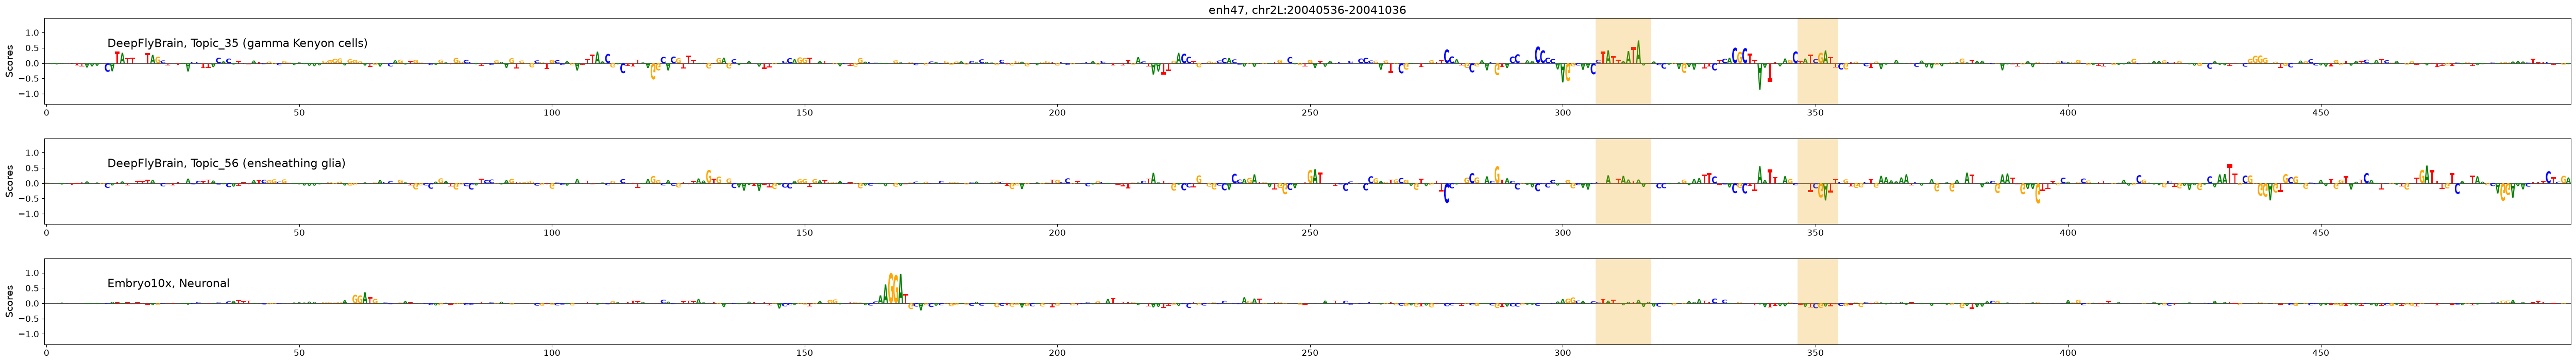

In [17]:
def scale(scores):
    """Rescale one model's contributions so its row fills the axis."""
    return scores / np.abs(scores).max()

three = np.concatenate([scale(enh_scores), scale(wrong_scores), scale(embryo_scores)],
                       axis=1)

crested.pl.explain.contribution_scores(
    three, enh_onehot,
    sequence_labels=[f"{enh_name}, {enh_region}"],
    class_labels=[
        "DeepFlyBrain, Topic_35 (gamma Kenyon cells)",
        "DeepFlyBrain, Topic_56 (ensheathing glia)",
        "Embryo10x, Neuronal",
    ],
    highlight_positions=[(int(h.start), int(h.end)) for h in found.itertuples()],
    highlight_kws={"facecolor": "#f0a202", "alpha": 0.25, "edgecolor": "none"},
)

The Onecut site is marked in all three rows.

- **Top.** Asked about gamma Kenyon cells, the correct cell type, the model
  leans almost entirely on that site.
- **Middle.** Asked about ensheathing glia, the same model reads the same
  sequence and depends on different positions. Each row is scaled to its own
  maximum, so in raw numbers this row is much smaller.
- **Bottom.** The embryo model, asked about generic neurons, uses different
  nucleotides again.

### Putting a number on it

Eyeballing plots is not a measurement.

In [18]:
def agreement(scores_a, scores_b, n_top=40):
    a, b = importance(scores_a), importance(scores_b)
    shared = len(set(np.argsort(a)[-n_top:]) & set(np.argsort(b)[-n_top:]))
    return np.corrcoef(a, b)[0, 1], shared

corr, shared = agreement(enh_scores, embryo_scores)
print(f"{enh_name}, DeepFlyBrain (gamma Kenyon cells) vs Embryo10x (Neuronal)")
print(f"   correlation of per-nucleotide importance: {corr:.2f}")
print(f"   of the 40 most important positions, shared: {shared}")

enh47, DeepFlyBrain (gamma Kenyon cells) vs Embryo10x (Neuronal)
   correlation of per-nucleotide importance: 0.06
   of the 40 most important positions, shared: 5


The two models largely disagree about which nucleotides matter here. That is the
expected result rather than a problem: this is a Kenyon cell enhancer, and only
DeepFlyBrain was trained on Kenyon cells. The embryo model has no Kenyon cell
class and answers with whatever generic neuronal features it has.

The lesson runs both ways. Where two independently trained models converge on the
same positions, that is better evidence than either alone. Where they diverge,
look first at what each was trained on.

## 7. Your turn

### Choosing an enhancer worth looking at

A high prediction score does not guarantee an interesting contribution plot.
Some regions score well but spread their signal thinly across the sequence, and
there is nothing to see. Score the enhancers on both: how confident the call is,
and how concentrated the contributions are.

In [19]:
all_seqs = crested.utils.fetch_sequences(list(tested["region"]), genome)
all_preds = crested.tl.predict(all_seqs, model, batch_size=32)

annotated_only = all_preds[:, topic_index]
tested["call"] = [topic_labels[i] for i in annotated_only.argmax(axis=1)]
tested["score"] = annotated_only.max(axis=1).round(3)

tested.sort_values("score", ascending=False)[["name", "region", "call", "score"]].head(10)

1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step


,name,region,call,score
50,enh52,chr2L:11228149-11228649,Gamma Kenyon cells (35),0.955
38,enh26,chr2L:15023029-15023529,Alpha/Beta Kenyon cells (21),0.918
18,enh08,chr3L:9193158-9193658,Alpha'/Beta' Kenyon cells (77),0.906
15,enh48,chr2L:9842052-9842552,Alpha'/Beta' Kenyon cells (77),0.888
1,enh19,chr3L:9525672-9526172,T1 (23),0.886
29,enh38,chr3R:20519008-20519508,T2a (44),0.858
39,enh30,chr3L:8865058-8865558,Ensheathing glia (partly) (72),0.804
51,enh54,chr2L:3448099-3448599,Alpha/Beta Kenyon cells (21),0.756
10,enh04,chrX:535086-535586,Alpha'/Beta' Kenyon cells (77),0.738
9,enh61,chr2R:9760498-9760998,Alpha/Beta Kenyon cells (21),0.736


Pick one and look at it. Change `PICK`, and the transcription factors you scan
for, and lower `threshold` if nothing is found.

Some that work well, one per cell class:

| enhancer | model call | motif found | how far above average |
|---|---|---|---|
| `enh40` | gamma Kenyon cells | onecut | 3.0x |
| `enh38` | T2a | fkh | 2.8x |
| `enh05` | alpha'/beta' Kenyon cells | sr | 2.8x |
| `enh12` | alpha/beta Kenyon cells | fkh | 1.7x |

`enh52` is an instructive counter-example. It has the highest prediction of all
54, at 0.955, and its contributions are concentrated in one short stretch, but
none of the motifs scanned for here match it. A model can depend on something
you have no name for.

enh38: chr3R:20519008-20519508, called T2a (44) at 0.8579999804496765
2026-09-23T16:48:32.794861+0200 INFO Calculating contribution scores for 1 region(s) and 1 class(es).


Model:   0%|          | 0/1 [00:00<?, ?it/s]

Model: 100%|██████████| 1/1 [00:00<00:00,  5.08it/s]

Model: 100%|██████████| 1/1 [00:00<00:00,  5.05it/s]

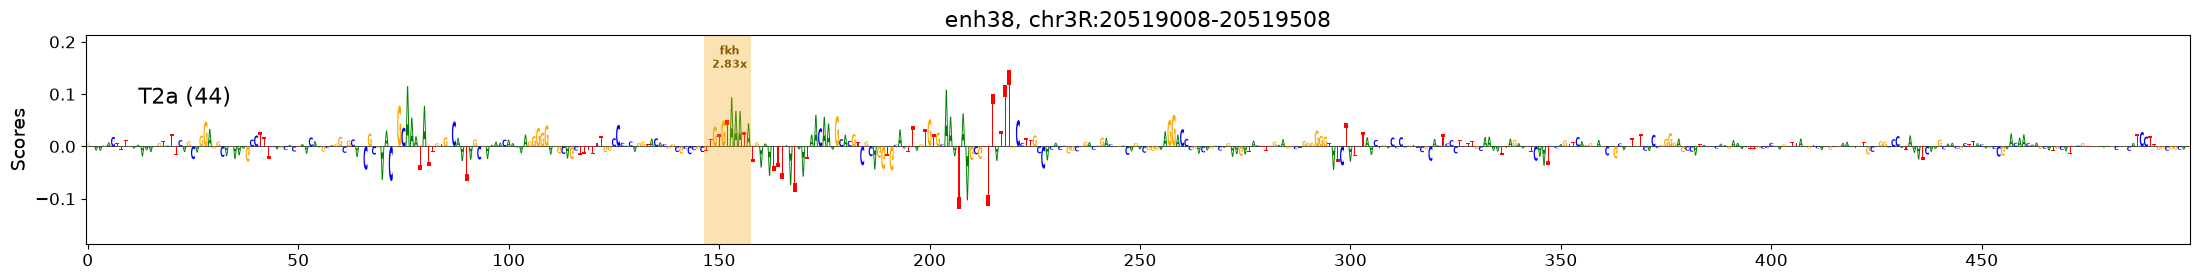

,tf,start,end,strand,sequence,score,x_average
0,fkh,147,158,+,TTGTGTAAATA,0.911,2.83


In [20]:
PICK = "enh38"                                            # change this
TFS = ["Mef2", "ey", "sr", "onecut", "fkh", "acj6"]       # and these

row = tested.loc[tested["name"] == PICK].iloc[0]
pick_seq = crested.utils.fetch_sequences([row["region"]], genome)[0]
pick_topic = int(row["call"].split("(")[-1].rstrip(")")) - 1
print(f"{PICK}: {row['region']}, called {row['call']} at {row['score']}")

pick_scores, pick_onehot = crested.tl.contribution_scores(
    [pick_seq], target_idx=pick_topic, model=model,
    method="integrated_grad", genome=genome,
)

pick_found = motifs_the_model_uses(pick_seq, pick_scores, TFS)
plot_with_motifs(pick_scores, pick_onehot, pick_found,
                 f"{PICK}, {row['region']}", row["call"])
pick_found

Questions to ask about your plot:

- Is the signal concentrated in a few places, or spread thinly? Spread out means
  the model has no clear reason for its call, whatever the score
- Does a motif land on the tallest stretch?
- Is the factor you found one you would expect in that cell type? Compare with
  the transcription factor markers from Practical 5

### Or a region of your own

Any 500 bp region works. Take the centre of a peak and 250 bp either side.

Use one you found in Practical 5,
or edit the coordinates below.

The region must be exactly 500 bp. Take the centre of a peak and 250 bp either
side.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step


2026-09-23T16:48:33.915603+0200 WARNING Argument `x_label_rotation` is renamed in v1.7.0; please use xtick_rotation instead.


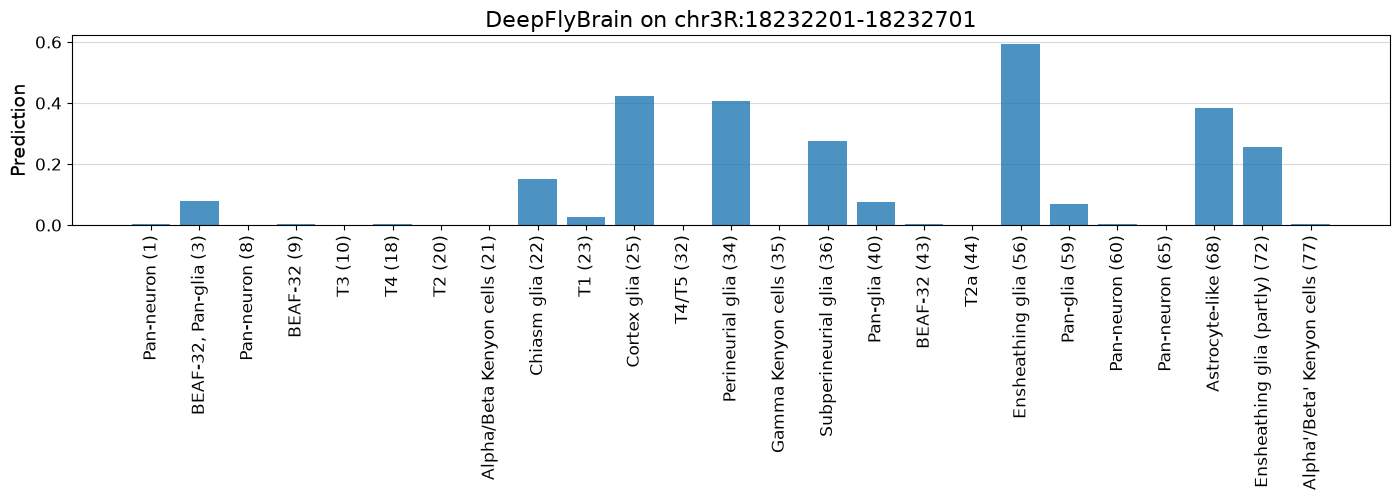

In [21]:
MY_REGION = "chr3R:18232201-18232701"     # change this

my_seq = crested.utils.fetch_sequences([MY_REGION], genome)[0]

crested.pl.region.bar(
    data=crested.tl.predict(my_seq, model).ravel()[topic_index],
    classes=topic_labels, title=f"DeepFlyBrain on {MY_REGION}",
    width=14, height=5, x_label_rotation=90,
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


2026-09-23T16:48:34.036865+0200 WARNING Argument `x_label_rotation` is renamed in v1.7.0; please use xtick_rotation instead.


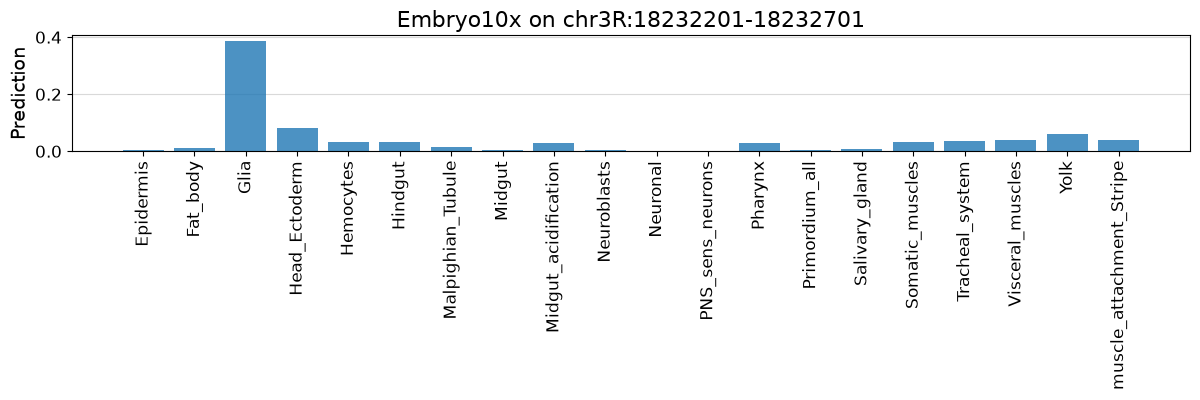

In [22]:
crested.pl.region.bar(
    data=crested.tl.predict(my_seq, embryo_model).ravel(),
    classes=embryo_classes, title=f"Embryo10x on {MY_REGION}",
    width=12, height=4, x_label_rotation=90,
)

Questions to ask about your plots:

- Are any bars tall? If everything is near zero in both models, neither
  recognises the region as anything it was trained on
- Do the tall bars agree with the cell type whose bigwig showed the peak in
  Practical 5?
- Do the two models agree at the level they can? A region both call glial is
  better supported than one only DeepFlyBrain calls glial

To see which nucleotides drove your result, put `MY_REGION` through the contribution
score cells in section 6, changing `target_idx` to the output you want explained.

## 8. What these models cannot do

Knowing the limits of a tool matters as much as knowing its output.

- **Each knows only its own cells.** DeepFlyBrain covers Kenyon cells, T neurons
  and glia of the adult brain; Embryo10x covers embryonic tissues at one stage.
  Neither has a dopaminergic class, so neither can answer the Parkinson's
  question in project 3, and neither was trained on the larval brain.
- **55 of DeepFlyBrain's 81 topics are unannotated.** A confident prediction for
  an unannotated topic is not interpretable.
- **They report resemblance, not causation.** A high score means the sequence
  looks like regions open in that cell type. It is not proof that the region is
  an enhancer, nor that it regulates the neighbouring gene. That needs an
  experiment: clone the 500 bp in front of a reporter and look at the fly.
- **Contribution scores are the model's reasoning, not the cell's.** Section 6
  showed two models reading different nucleotides in the same sequence and reaching
  the same conclusion. At most one of them can be reading it the way the cell
  does, and possibly neither.

Try a region from a cell type neither model saw, for instance a dopaminergic peak
from the Merrill data, and compare the plots with the ones above. Recognising
what a model looks like when asked a question outside its training data is a
genuinely useful skill, and section 5 gives you the reference for what a partial
answer looks like.

## Summary

In this practical you:

1. Loaded a pretrained network that maps 500 bp of DNA to 81 topic scores, and
   used the 26 annotated topics to label the plots with cell types
2. Saw it place a glial region in glia and a Kenyon cell region in Kenyon cells,
   from sequence alone
3. Compared it with a second model trained on embryos, which separated neuron
   from glia but could not name the cell type, because its training data did not
   contain one
4. Used contribution scores to see which nucleotides each model relies on, and found
   that the same sequence explained against the wrong cell type is nearly flat
5. Measured how far the two models agree on which bases matter, and found better
   agreement for the cell type they both know
6. Listed what the models cannot be asked

**For the group project**, keep: the region, its prediction bar plots from both
models, the contribution score figure, and one sentence on what you think binds
there and why.